# Import, adattisztítás

In [1]:
from fbref_module import *

url = "https://fbref.com/en/comps/8/schedule/Champions-League-Scores-and-Fixtures"
table_id = "sched_all"

ucl_data_raw = scrape(url, table_id)
print(ucl_data_raw.shape)

(155, 15)


In [60]:
# Clean data
import pandas as pd
import numpy as np
from datetime import datetime
import re

def clean_team_name(name):
    # töröljük az országkódokat az elejéről vagy a végéről
    name = re.sub(r'\b[a-z]{2,3}\b', '', name)  # országkód törlése
    name = name.replace('.', '').strip()
    return re.sub(r'\s+', ' ', name)  # extra szóközök eltüntetése

ucl_data_raw['Home'] = ucl_data_raw['Home'].apply(clean_team_name)
ucl_data_raw['Away'] = ucl_data_raw['Away'].apply(clean_team_name)

ucl_data_raw = ucl_data_raw[pd.notna(ucl_data_raw.Date) & (ucl_data_raw.Date != 'Date')]

ucl_data_raw['Goals_Home'] = ucl_data_raw['Score'].str.split('–').str[0]
ucl_data_raw['Goals_Away'] = ucl_data_raw['Score'].str.split('–').str[1]

ucl_data_raw.rename(columns={'xG': 'xG_Home', 'xG.1': 'xG_Away'}, inplace=True)


ucl_data_raw['Points_Home'] = np.where(ucl_data_raw.Goals_Home > ucl_data_raw.Goals_Away,
                                       3, np.where(ucl_data_raw.Goals_Home == ucl_data_raw.Goals_Away,
                                                   1, 0)
                                        )

ucl_data_raw['Points_Away'] = np.where(ucl_data_raw.Goals_Home < ucl_data_raw.Goals_Away,
                                       3, np.where(ucl_data_raw.Goals_Home == ucl_data_raw.Goals_Away,
                                                   1, 0)
                                        )


ucl_data_raw.Date = pd.to_datetime(ucl_data_raw.Date, format='%Y-%m-%d')
ucl_data_raw[['Goals_Home', 'Goals_Away', 
              'Points_Home', 'Points_Away',
              'xG_Home', 'xG_Away']] = ucl_data_raw[['Goals_Home', 'Goals_Away', 
                                                'Points_Home', 'Points_Away',
                                                'xG_Home', 'xG_Away']].astype(float)


mask = (ucl_data_raw['Date'] <= datetime.today())
ucl_data = ucl_data_raw.loc[mask, ['Date', 'Home', 'Away', 
                               'Goals_Home', 'Goals_Away', 
                               'xG_Home', 'xG_Away', 
                               'Points_Home', 'Points_Away']].copy()

print(f"\nMatches played: {len(ucl_data)}/{len(ucl_data_raw)}")
print(f"\nMatches with score: {len(ucl_data[(ucl_data.Goals_Home != 0) & (ucl_data.Goals_Away != 0)])}/{len(ucl_data)}")

display(ucl_data.head())


Matches played: 72/144

Matches with score: 39/72


,Date,Home,Away,Goals_Home,Goals_Away,xG_Home,xG_Away,Points_Home,Points_Away
0,2025-09-16,PSV Eindhoven,Union SG,1.0,3.0,2.1,3.0,0.0,3.0
1,2025-09-16,Athletic Club,Arsenal,0.0,2.0,0.3,1.3,0.0,3.0
2,2025-09-16,Tottenham,Villarreal,1.0,0.0,0.5,0.5,3.0,0.0
3,2025-09-16,Benfica,Qarabağ,2.0,3.0,1.4,1.5,0.0,3.0
4,2025-09-16,Juventus,Dortmund,4.0,4.0,1.9,1.5,1.0,1.0


In [61]:
# Pots

pot_dict = {
    # --- Pot 1 ---
    "Paris S-G": 1,
    "Real Madrid": 1,
    "Manchester City": 1,
    "Bayern Munich": 1,
    "Liverpool": 1,
    "Inter": 1,
    "Chelsea": 1,
    "Dortmund": 1,
    "Barcelona": 1,

    # --- Pot 2 ---
    "Arsenal": 2,
    "Leverkusen": 2,
    "Atlético Madrid": 2,
    "Benfica": 2,
    "Atalanta": 2,
    "Villarreal": 2,
    "Juventus": 2,
    "Eint Frankfurt": 2,
    "Club Brugge": 2,

    # --- Pot 3 ---
    "Tottenham": 3,
    "PSV Eindhoven": 3,
    "Ajax": 3,
    "Napoli": 3,
    "Sporting CP": 3,
    "Olympiacos": 3,
    "Slavia Prague": 3,
    "Bodø/Glimt": 3,
    "Marseille": 3,

    # --- Pot 4 ---
    "FC Copenhagen": 4,
    "Monaco": 4,
    "Galatasaray": 4,
    "Union SG": 4,
    "Qarabağ": 4,
    "Athletic Club": 4,
    "Newcastle Utd": 4,
    "Pafos FC": 4,
    "Qaırat Almaty": 4
}

ucl_data['Pot_Home'] = ucl_data['Home'].map(pot_dict)
ucl_data['Pot_Away'] = ucl_data['Away'].map(pot_dict)

# ellenőrzés, hogy nincs-e hiányzó érték
missing_teams = set(ucl_data['Home']).union(ucl_data['Away']) - set(pot_dict.keys())
print("Hiányzó a pot dictionary-ből:", missing_teams)

ucl_data.head()

Hiányzó a pot dictionary-ből: set()


,Date,Home,Away,Goals_Home,Goals_Away,xG_Home,xG_Away,Points_Home,Points_Away,Pot_Home,Pot_Away
0,2025-09-16,PSV Eindhoven,Union SG,1.0,3.0,2.1,3.0,0.0,3.0,3,4
1,2025-09-16,Athletic Club,Arsenal,0.0,2.0,0.3,1.3,0.0,3.0,4,2
2,2025-09-16,Tottenham,Villarreal,1.0,0.0,0.5,0.5,3.0,0.0,3,2
3,2025-09-16,Benfica,Qarabağ,2.0,3.0,1.4,1.5,0.0,3.0,2,4
4,2025-09-16,Juventus,Dortmund,4.0,4.0,1.9,1.5,1.0,1.0,2,1


# Kalapok szerint

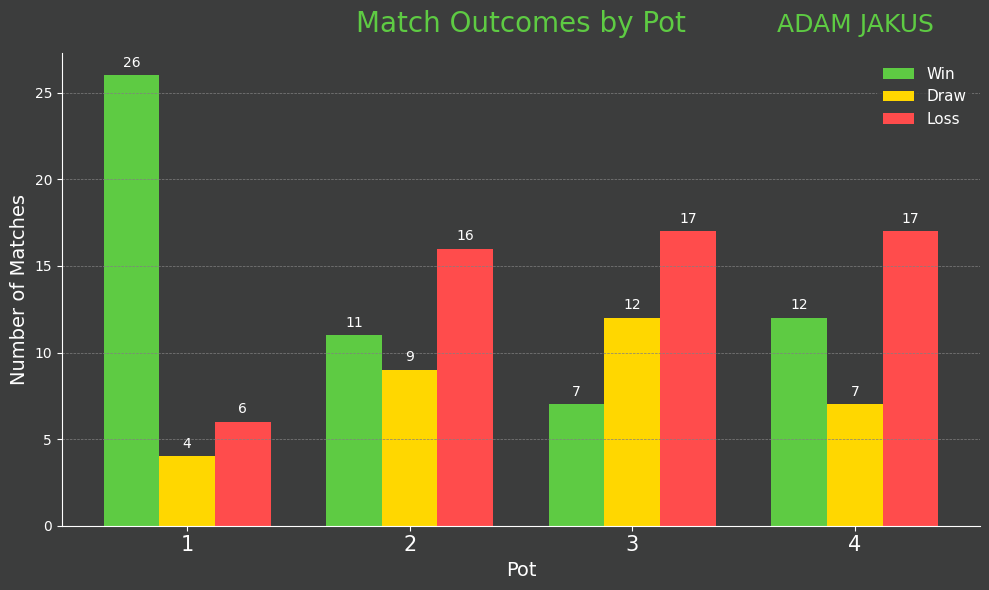

In [62]:
# Outcomes by pot

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import os

# ---- STYLE ----
background_color = '#3c3d3d'
text_color = '#5ECB43'
font_path = os.getcwd() + r'\Athletic\Nexa-ExtraLight.ttf'  # ha létezik a font
if os.path.exists(font_path):
    font_props = font_manager.FontProperties(fname=font_path)
else:
    font_props = None  # fallback ha nem található a font

# ---- PREP DATA ----
home_df = ucl_data[['Pot_Home', 'Points_Home']].rename(columns={'Pot_Home': 'Pot', 'Points_Home': 'Points'})
away_df = ucl_data[['Pot_Away', 'Points_Away']].rename(columns={'Pot_Away': 'Pot', 'Points_Away': 'Points'})
combined = pd.concat([home_df, away_df], ignore_index=True)
combined['Result'] = combined['Points'].map({3: 'Win', 1: 'Draw', 0: 'Loss'})

summary = combined.groupby(['Pot', 'Result']).size().unstack(fill_value=0)
summary = summary[['Win', 'Draw', 'Loss']]  # biztosítsuk a sorrendet

# ---- CHART ----
fig, ax = plt.subplots(figsize=(10, 6), facecolor=background_color)
ax.set_facecolor(background_color)

# Színek: Win – Draw – Loss
colors = {
    'Win': '#5ECB43',   # zöld
    'Draw': '#FFD700',  # sárga
    'Loss': '#FF4C4C'   # piros
}

# Egymás melletti (nem stacked) barplot
width = 0.25
x = range(1, 5)
for i, result in enumerate(summary.columns):
    ax.bar(
        [p + (i - 1) * width for p in x],
        summary[result],
        width=width,
        label=result,
        color=colors[result]
    )

# Adatfeliratok a barok tetejére
for i, result in enumerate(summary.columns):
    for pot, value in zip(x, summary[result]):
        ax.text(
            pot + (i - 1) * width,
            value + 0.5,
            str(value),
            ha='center',
            color='white',
            fontsize=10
        )

# ---- FORMATTING ----
ax.set_title('Match Outcomes by Pot', color=text_color, fontsize=20, pad=15)
ax.set_xlabel('Pot', color='white', fontsize=14)
ax.set_ylabel('Number of Matches', color='white', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x], fontsize=15, color='white')
ax.legend(
    facecolor=background_color,
    edgecolor='none',
    labelcolor='white',
    fontsize=11,
    loc='upper right'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)

# ---- WATERMARK ----
fig.text(
    0.86, 0.95,
    'ADAM JAKUS',
    color=text_color,
    fontsize=18,
    fontproperties=font_props,
    ha='center',
    va='center'
)

plt.tight_layout()
plt.show()


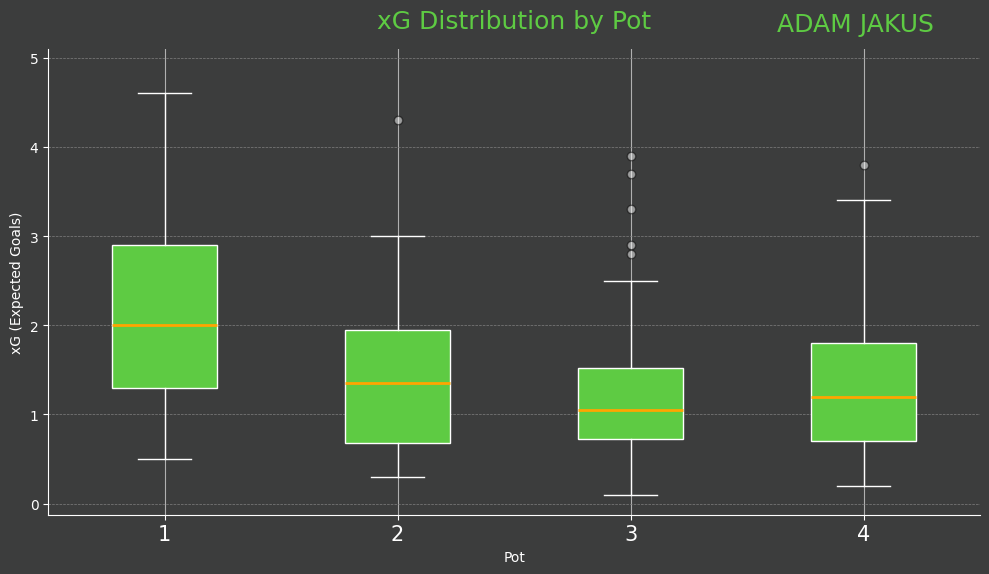

In [63]:
# xG by pot boxplot

# Home és Away xG adatok egyesítése
home_xg = ucl_data[['Pot_Home', 'xG_Home']].rename(columns={'Pot_Home': 'Pot', 'xG_Home': 'xG'})
away_xg = ucl_data[['Pot_Away', 'xG_Away']].rename(columns={'Pot_Away': 'Pot', 'xG_Away': 'xG'})
xg_data = pd.concat([home_xg, away_xg], ignore_index=True)

# Boxplot készítése
fig, ax = plt.subplots(figsize=(10, 6), facecolor=background_color)
ax.set_facecolor(background_color)

xg_data['xG'] = pd.to_numeric(xg_data['xG'], errors='coerce')

bp = xg_data.boxplot(
    column='xG', by='Pot', ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#5ECB43', color='white'),
    whiskerprops=dict(color='white'),
    capprops=dict(color='white'),
    medianprops=dict(color='orange', linewidth=2),
    flierprops=dict(marker='o', markerfacecolor='white', alpha=0.5)
)

plt.suptitle('')
ax.set_title('xG Distribution by Pot', color=text_color, fontsize=18, pad=15)
ax.set_xlabel('Pot', color='white')
ax.set_ylabel('xG (Expected Goals)', color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')
ax.set_xticks(x)
ax.set_xticklabels([str(i) for i in x], fontsize=15)
ax.set_ylim(top=5.1)
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5)

# ---- WATERMARK ----
fig.text(
    0.86, 0.925,
    'ADAM JAKUS',
    color=text_color,
    fontsize=18,
    fontproperties=font_props,
    ha='center',
    va='center'
)

plt.tight_layout()
plt.show()


# Erőviszony mátrix

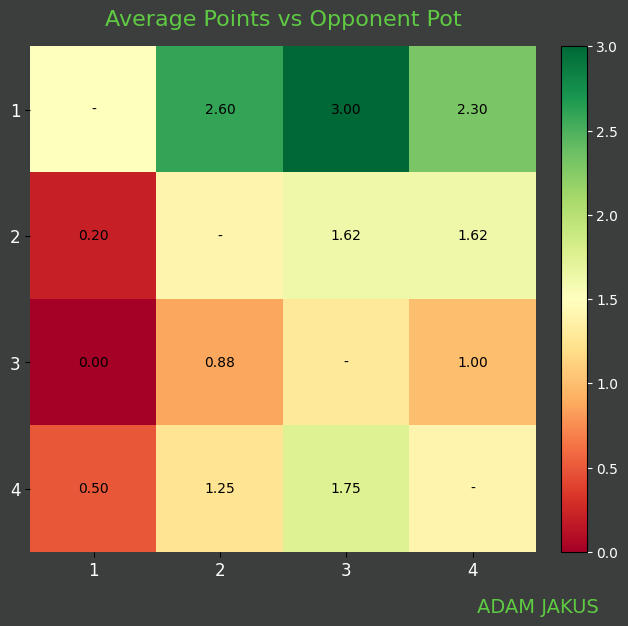

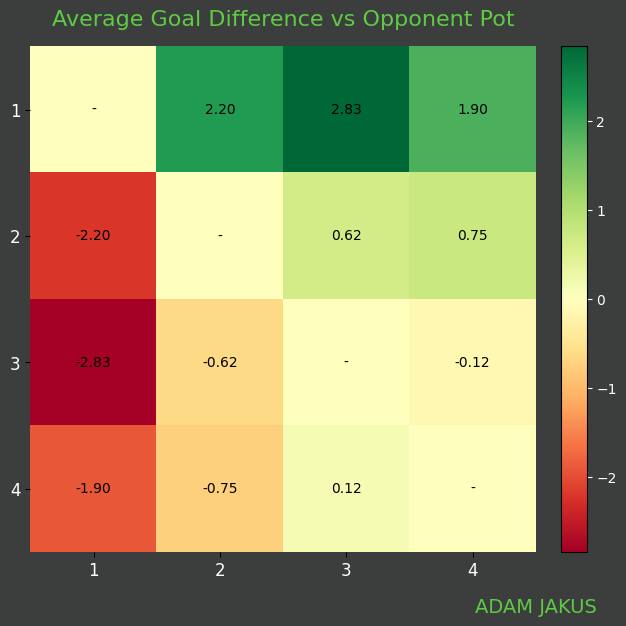

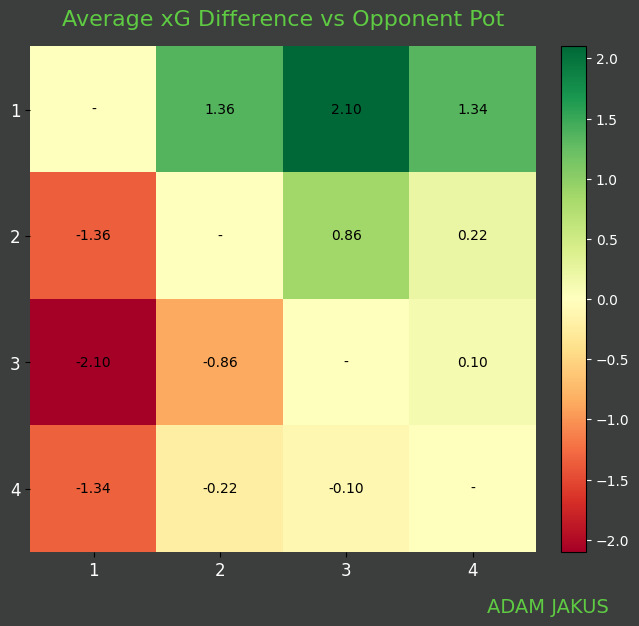

In [77]:
# Matrices

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

# ---------- STYLE ----------
background_color = '#3c3d3d'
text_color = '#5ECB43'

# ---------- DATA PREP ----------
df = ucl_data.copy()

# Gólkülönbség és xG-különbség számítása
df["Goal_Diff_Home"] = df["Goals_Home"] - df["Goals_Away"]
df["Goal_Diff_Away"] = -df["Goal_Diff_Home"]
df["xG_Diff_Home"] = df["xG_Home"] - df["xG_Away"]
df["xG_Diff_Away"] = -df["xG_Diff_Home"]

# Home és Away egyesítése (hogy minden meccs két irányból szerepeljen)
home_df = df[["Pot_Home", "Pot_Away", "Points_Home", "Goal_Diff_Home", "xG_Diff_Home"]].rename(
    columns={"Pot_Home": "Pot", "Pot_Away": "OppPot", 
             "Points_Home": "Points", "Goal_Diff_Home": "Goal_Diff", "xG_Diff_Home": "xG_Diff"})
away_df = df[["Pot_Away", "Pot_Home", "Points_Away", "Goal_Diff_Away", "xG_Diff_Away"]].rename(
    columns={"Pot_Away": "Pot", "Pot_Home": "OppPot", 
             "Points_Away": "Points", "Goal_Diff_Away": "Goal_Diff", "xG_Diff_Away": "xG_Diff"})
combined = pd.concat([home_df, away_df], ignore_index=True)

# ---------- HELPER FUNCTION ----------
def plot_heatmap(matrix, title, cmap, annot_fmt=".2f"):
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=background_color)
    ax.set_facecolor(background_color)

    cax = ax.imshow(matrix, cmap=cmap, interpolation='nearest')

    # Tengelyek
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, color='white', fontsize=12)
    ax.set_yticklabels(matrix.index, color='white', fontsize=12)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", rotation_mode="anchor")

    # Adatfeliratok
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            text = f"{matrix.iloc[i, j]:{annot_fmt}}" if i!=j else "-"
            ax.text(j, i, text,
                    ha="center", va="center", color="black", fontsize=10)

    # Cím
    ax.set_title(title, color=text_color, fontsize=16, pad=15)

    # Szegélyek, rács
    ax.spines[:].set_visible(False)
    plt.grid(False)

    # Színtér
    cbar = plt.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    # Watermark
    fig.text(0.86, -0.02, 'ADAM JAKUS', color=text_color, fontsize=14, ha='center', va='center')

    plt.tight_layout()
    plt.show()

combined["Pot"] = combined["Pot"].astype(str)
combined["OppPot"] = combined["OppPot"].astype(str)

# ---------- 1. Átlagpontok ----------
avg_points = combined.groupby(["Pot", "OppPot"])["Points"].mean().unstack()
avg_points = avg_points.reindex(["1", "2", "3", "4"], axis=0).reindex(["1", "2", "3", "4"], axis=1)
plot_heatmap(avg_points, "Average Points vs Opponent Pot", cmap="RdYlGn")

# ---------- 2. Átlagos gólkülönbség ----------
avg_goal_diff = combined.groupby(["Pot", "OppPot"])["Goal_Diff"].mean().unstack()
avg_goal_diff = avg_goal_diff.reindex(["1", "2", "3", "4"], axis=0).reindex(["1", "2", "3", "4"], axis=1)
plot_heatmap(avg_goal_diff, "Average Goal Difference vs Opponent Pot", cmap="RdYlGn")

# ---------- 3. Átlagos xG-különbség ----------
avg_xg_diff = combined.groupby(["Pot", "OppPot"])["xG_Diff"].mean().unstack()
avg_xg_diff = avg_xg_diff.reindex(["1", "2", "3", "4"], axis=0).reindex(["1", "2", "3", "4"], axis=1)
plot_heatmap(avg_xg_diff, "Average xG Difference vs Opponent Pot", cmap="RdYlGn")


# Pontszerzés, gólkülönbség, xG különbség kalaponként

# Hazai-idegenbeli különbségek kalaponként

# Meglepetésindex

# Alul- és felülteljesítők